In [1]:
import pandas as pd
import os, json
from datetime import datetime
import matplotlib.pyplot as plt 
import matplotlib as mpl
from matplotlib.cm import get_cmap
import numpy as np
import string
from utils import  get_codebook_object_from_json, convert_textdf_to_numeric_response_df

In [2]:
gpt_res_dir     = os.path.join(os.getcwd(),  'gpt-deductions')
transcripts_dir = os.path.join(os.getcwd(), 'transcripts')
errors_dir      = os.path.join(os.getcwd(), 'gpt-errors')
if not os.path.exists(errors_dir):
    os.makedirs(errors_dir)


codebook_file   = os.path.join(transcripts_dir, 'codebook.json')
with open(codebook_file, 'r') as file:
    codebook_json = json.load(file)
codebook = get_codebook_object_from_json(codebook_json)

In [3]:
def compute_accuracies(correct_df_text, predicted_df_text, pid):
    #file to save prediction errors
    errors_file = os.path.join(errors_dir, f"participant{pid}_errors.txt")
    accuracies = []
    code_to_accuracy = {}
    #convert text answers to correspondening numeric encodings
    correct_df            = convert_textdf_to_numeric_response_df(codebook, correct_df_text)
    predicted_df          = convert_textdf_to_numeric_response_df(codebook, predicted_df_text)
    #compute accuracies and save errors
    with open(errors_file, 'w') as file:
        for code in correct_df.keys():
            if  "Unnamed" in code: continue
            if code == 'PHYS11_TEMP':
                predicted_series = predicted_df[code].astype(float)
                actual_series    = correct_df[code].astype(float)
            else:
                predicted_series = predicted_df[code].astype(int)
                actual_series    = correct_df[code].astype(int)

            match = predicted_series == actual_series
            false_predictions    = predicted_df_text[code][~match]
            expected_predictions = correct_df_text[code][~match]
            
            for i, pred in false_predictions.items():
                #print(f"Persona: {i+1} question: {code} predicted: {pred}  actual: {expected_predictions[i]}")
                file.write(f"Persona: {i+1} question: {code} predicted: {pred}  actual: {expected_predictions[i]}\n")
            accuracy = match.sum()/len(match)
            code_to_accuracy[code] = accuracy
            accuracies.append(accuracy)
            
            #if len(false_predictions) > 0: print(code, accuracy)
            
    
    #print(f"Average accuracy: {np.mean(accuracies)}")
    return code_to_accuracy

In [4]:
participant_ids    = [i+1 for i in range(8)]
code_to_accuracies = {}
for pid in participant_ids:
    gpt_fname    = os.path.join(gpt_res_dir,     f"participant{pid}_deduced_2025-03-26.csv")
    survey_fname = os.path.join(transcripts_dir, f"participant{pid}/survey_responses.csv")
    correct_df_text       =  pd.read_csv(survey_fname).drop(columns=['Unnamed: 0'])
    predicted_df_text     =  pd.read_csv(gpt_fname)
    code_to_accuracy = compute_accuracies(correct_df_text, predicted_df_text, pid)
    for code in code_to_accuracy:
        if code not in code_to_accuracies: code_to_accuracies[code] = []
        code_to_accuracies[code].append(code_to_accuracy[code])


accuracy_df = pd.DataFrame(code_to_accuracies)
accuracy_df.head(8)   

,AGE7,GENDER,RACETH,HHINCOME,EDUCATION,HHSIZE1,HH01S,HH25S,HH612S,HH1317S,...,PHYS1C,PHYS1D,PHYS1E,PHYS1F,PHYS1G,PHYS1H,PHYS1I,PHYS1J,PHYS11,PHYS11_TEMP
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,0.8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1.0,0.8,1.0,0.8,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,0.8,0.8,0.8,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.8,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,0.8,0.8,1.0,1.0,0.8,0.8,0.8,0.8,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
6,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
7,1.0,1.0,1.0,0.8,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.8,1.0


In [5]:
avg_accuracies = accuracy_df.mean()
avg_accuracies

AGE7           1.000
GENDER         0.975
RACETH         0.925
HHINCOME       0.900
EDUCATION      0.975
HHSIZE1        1.000
HH01S          0.975
HH25S          0.975
HH612S         0.975
HH1317S        0.975
HH18OVS        0.975
SOC2A          0.975
SOC2B          0.975
SOC5A          1.000
SOC5B          0.950
SOC5C          1.000
SOC5D          1.000
SOC5E          1.000
ECON1          0.925
PHYS8          0.975
PHYS4          1.000
PHYS5          1.000
PHYS1B         0.975
PHYS1C         0.975
PHYS1D         1.000
PHYS1E         1.000
PHYS1F         0.975
PHYS1G         1.000
PHYS1H         1.000
PHYS1I         1.000
PHYS1J         1.000
PHYS11         0.975
PHYS11_TEMP    1.000
dtype: float64

In [6]:
print(avg_accuracies.mean(),  avg_accuracies.std())

0.9803030303030303 0.024809883172443654


In [7]:
def plot_per_question_accuracies(accuracies, figname =  "gpt_accuracies.pdf"):
    # Create figure and axis
    n_questions = len(accuracies)
    fig, ax = plt.subplots(figsize=(12, 6))   
    x_values = range(1, n_questions + 1) 
    
      
    #define color map
    cmap = mpl.colormaps["Blues"]#get_cmap('Blues')    
    normalized_indices = np.linspace(0.2, 0.8, n_questions)  
    colors = cmap(normalized_indices) 
    
    
    # Bar plot  
    ax.bar(x_values, accuracies, color=colors, width = 1, edgecolor='white')  
    ax.margins(x=0.01) 
    #ax.set_title('Accuracy vs question number', fontsize=12)  
    ax.set_xlabel('Question Number', fontsize=14)  
    ax.set_ylabel('Accuracy', fontsize=14)  
    ax.set_xticks(x_values)  
    ax.set_ylim([0.85, 1.0])
    ax.set_yticks([0.85, 0.9, 0.95, 1.0])
    ax.tick_params(axis='y', labelsize=13)
    ax.tick_params(axis='x', labelsize=13, labelrotation=60) 
    ax.grid(axis='y', linestyle='--', alpha=0.6)  
    
    # Remove plot border lines (spines)  
    ax.spines['top'].set_visible(False)   
    ax.spines['right'].set_visible(False)    
    #ax.spines['left'].set_visible(False)    
    
    plt.tight_layout()  
    plt.show() 
    fig.savefig(figname)

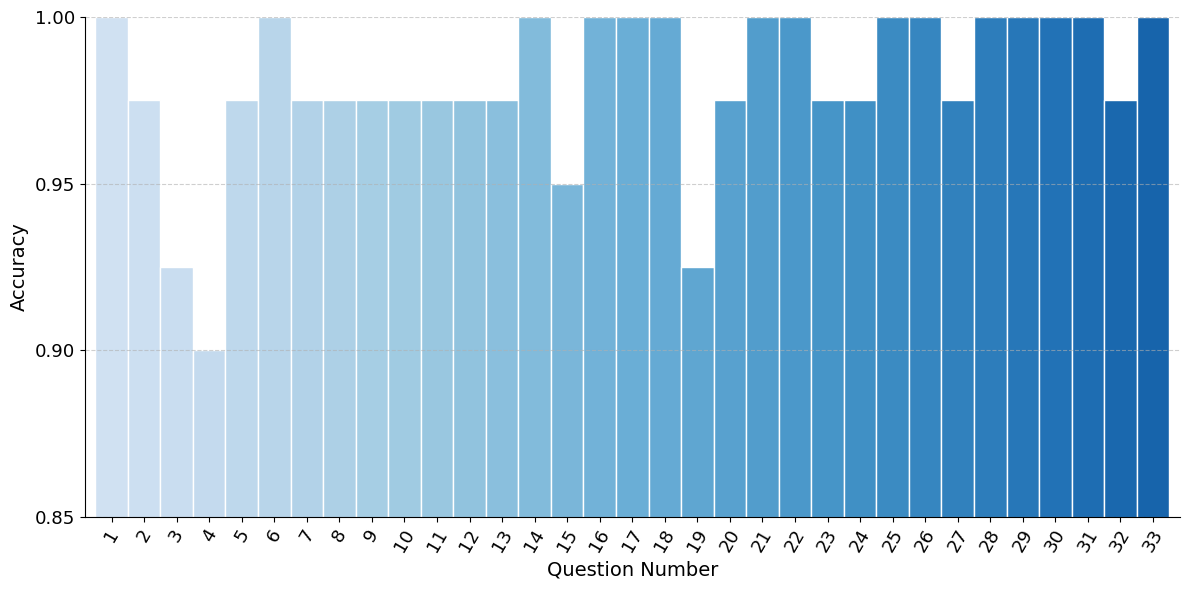

Average accuracy for participant 1: 99.4 ± 0.6
Average accuracy for participant 2: 98.8 ± 0.8
Average accuracy for participant 3: 97.6 ± 1.4
Average accuracy for participant 4: 96.4 ± 1.4
Average accuracy for participant 5: 95.8 ± 1.4
Average accuracy for participant 6: 99.4 ± 0.6
Average accuracy for participant 7: 98.2 ± 1.0
Average accuracy for participant 8: 98.8 ± 0.8


In [8]:
plots_dir = os.path.join(os.getcwd(), 'plots')
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)
plot_per_question_accuracies(avg_accuracies, figname =  os.path.join(plots_dir, "gpt_accuracies.pdf"))
for index, row in accuracy_df.iterrows():
    print( "Average accuracy for participant %d: %3.1f \u00b1 %1.1f" %(index+1, row.mean()*100, row.sem()*100))
    #plot_per_question_accuracies(row, figname =  os.path.join(plots_dir, f"participant{index+1}_gpt_accuracies.pdf"))